<a href="https://colab.research.google.com/github/SahilGaneshKarpate/28-assignment-/blob/main/28%20assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv(
    next(iter(uploaded)),
    sep=";",
    names=["text", "emotions"]
)

print(df.head(10))
print(df.shape)
print(df.isnull().sum())

Saving train.txt to train.txt
                                                text  emotions
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love
(16000, 2)
text        0
emotions    0
dtype: int64


In [3]:
from sklearn.preprocessing import LabelEncoder

print("Unique Emotion Labels:")
print(df["emotions"].unique())

le = LabelEncoder()

df["emotion_encoded"] = le.fit_transform(df["emotions"])

emotion_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("\nEmotion Mapping:")
print(emotion_mapping)

print("\nFirst 10 Rows:")
print(df.head(10))

Unique Emotion Labels:
['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']

Emotion Mapping:
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

First 10 Rows:
                                                text  emotions  \
0                            i didnt feel humiliated   sadness   
1  i can go from feeling so hopeless to so damned...   sadness   
2   im grabbing a minute to post i feel greedy wrong     anger   
3  i am ever feeling nostalgic about the fireplac...      love   
4                               i am feeling grouchy     anger   
5  ive been feeling a little burdened lately wasn...   sadness   
6  ive been taking or milligrams or times recomme...  surprise   
7  i feel as confused about life as a teenager or...      fear   
8  i have been with petronas for years i feel tha...       joy   
9                                i feel romantic too      love   

   emotion_encoded  
0         

In [4]:
print("Before Lowercasing:\n")
print(df["text"].head(5))

df["text_lower"] = df["text"].str.lower()

print("\nAfter Lowercasing:\n")
print(df["text_lower"].head(5))

Before Lowercasing:

0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object

After Lowercasing:

0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text_lower, dtype: object


In [5]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

print("Before Removing Punctuation:\n")
print(df["text_lower"].head(5))

df["text_no_punctuation"] = df["text_lower"].apply(remove_punctuation)

print("\nAfter Removing Punctuation:\n")
print(df["text_no_punctuation"].head(5))

Before Removing Punctuation:

0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text_lower, dtype: object

After Removing Punctuation:

0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text_no_punctuation, dtype: object


In [6]:
import re

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

print("Before Removing Numbers:\n")
print(df["text_no_punctuation"].head(5))

df["text_no_numbers"] = df["text_no_punctuation"].apply(remove_numbers)

print("\nAfter Removing Numbers:\n")
print(df["text_no_numbers"].head(5))

Before Removing Numbers:

0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text_no_punctuation, dtype: object

After Removing Numbers:

0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text_no_numbers, dtype: object


In [7]:
def remove_emojis_special(text):
    return text.encode("ascii", "ignore").decode()

df["text_ascii"] = df["text_no_numbers"].apply(remove_emojis_special)

print(df["text_ascii"].head(5))

0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text_ascii, dtype: object


In [8]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["text_no_stopwords"] = df["text_ascii"].apply(remove_stopwords)

print(df["text_no_stopwords"].head(5))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


0                                didnt feel humiliated
1    go feeling hopeless damned hopeful around some...
2            im grabbing minute post feel greedy wrong
3    ever feeling nostalgic fireplace know still pr...
4                                      feeling grouchy
Name: text_no_stopwords, dtype: object


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
import string
import re

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = text.encode("ascii", "ignore").decode()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["cleaned_text"] = df["text"].apply(clean_text)

print(df[["text", "cleaned_text"]].head(10))

                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   
5  ive been feeling a little burdened lately wasn...   
6  ive been taking or milligrams or times recomme...   
7  i feel as confused about life as a teenager or...   
8  i have been with petronas for years i feel tha...   
9                                i feel romantic too   

                                        cleaned_text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  
5      ive feeling little burdened lately wasnt sure 

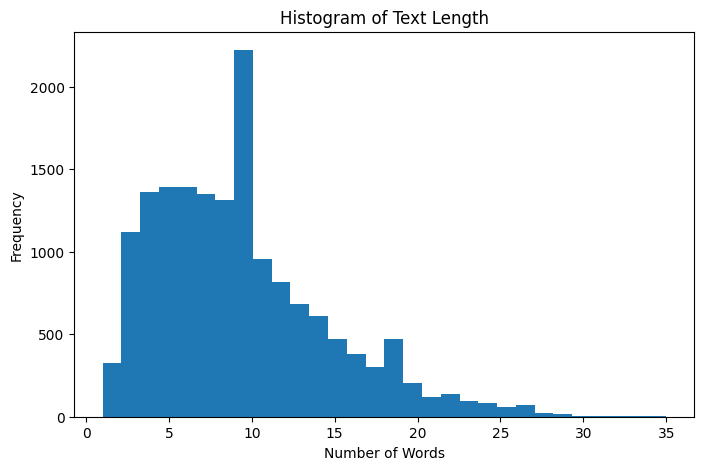

Average Length: 9.3530625
Minimum Length: 1
Maximum Length: 35


In [10]:
import matplotlib.pyplot as plt

df["text_length"] = df["cleaned_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=30)
plt.title("Histogram of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

print("Average Length:", df["text_length"].mean())
print("Minimum Length:", df["text_length"].min())
print("Maximum Length:", df["text_length"].max())

In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import string
import re
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

df = pd.read_csv(
    "train.txt",
    sep=";",
    names=["text", "emotions"]
)

encoder = LabelEncoder()
df["emotion_encoded"] = encoder.fit_transform(df["emotions"])

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = text.encode("ascii", "ignore").decode()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["cleaned_text"] = df["text"].apply(clean_text)

df.to_csv("cleaned_emotions.csv", index=False)

print(df["emotions"].value_counts())
print("\nCleaned dataset saved as cleaned_emotions.csv")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

Cleaned dataset saved as cleaned_emotions.csv
